[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link]
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-PACE/pace-aph.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a> [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link]

[download-link]: https://nmfs-opensci.github.io/NMFSHackDays-2025/topics-2025/2025-PACE/pace-aph.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-PACE/pace-aph.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2025/main/topics-2025/2025-PACE/pace-aph.ipynb

>📘 Learning Objectives
>
> 1. Show how to work with the `earthaccess` package for PACE data
> 2. Create a NASA EDL session for authentication
> 3. Load single files with `xarray.open_dataset`
> 4. Load multiple files with `xarray.open_mfdataset`

## Overview

The PACE Level-3 (gridded) OCI (ocean color instrument) data is available on an NASA EarthData. Search using the instrument filter "OCI" and processing level filter "Gridded Observations" <https://search.earthdata.nasa.gov/search?fi=OCI&fl=3%2B-%2BGridded%2BObservations> and you will see 45+ data collections. In this tutorial, we will look at the Spectral phytoplankton absorption coefficients (APH) product.

APH is in the IOP collection: [PACE OCI Level-3 Global Mapped Inherent Optical Properties (IOP) Data, version 3.0](https://cmr.earthdata.nasa.gov/search/concepts/C3385050632-OB_CLOUD.html). The concept id for this dataset is "C3385050632-OB_CLOUD" and the short name is "PACE_OCI_L3M_IOP".



### Prerequisites

You need to have an EarthData Login username and password. Go here to get one <https://urs.earthdata.nasa.gov/>

I assume you have a `.netrc` file at `~` (home). `~/.netrc` should look just like this with your username and password. Create that file if needed. You don't need to create it if you don't have this file. The `earthaccess.login(persist=True)` line will ask for your username and password and create the `.netrc` file for you.

```
machine urs.earthdata.nasa.gov
        login yourusername
        password yourpassword
```

#### For those not working in the JupyterHub

Uncomment this line and run the cell:

In [1]:
# pip install earthaccess

### Create a NASA EDL authenticated session

Authenticate with `earthaccess.login()`.Authenticate with `earthaccess.login()`. You will need your EarthData Login username and password for this step. Get one here [https://urs.earthdata.nasa.gov/](https://urs.earthdata.nasa.gov/).

In [1]:
import earthaccess
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

### Import Required Packages

In [2]:
import xarray as xr

## Monthly data

I poked around on the files on [search.earthdata](https://search.earthdata.nasa.gov/search/granules/collection-details?p=C3385050418-OB_CLOUD&pg[0][v]=f&pg[0][gsk]=-start_date&fi=OCI&fl=3%2B-%2BGridded%2BObservations&tl=1726833236.2!4!!&lat=0.0703125) so I know what the files look like. March to December 2024.

In [18]:
import earthaccess
results_mo = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_IOP",
    temporal = ("2024-03-01", "2024-12-31"),
    granule_name="*.MO.*aph.0p1deg.*"
)
len(results_mo)

10

In [5]:
results_mo[0]

Collection: {'Version': '3.0', 'ShortName': 'PACE_OCI_L3M_IOP'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'SouthBoundingCoordinate': -90, 'WestBoundingCoordinate': -180, 'EastBoundingCoordinate': 180, 'NorthBoundingCoordinate': 90}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-03-05T00:00:00Z', 'EndingDateTime': '2024-03-31T23:59:59Z'}}
Size(MB): 30.997425079345703
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240301_20240331.L3m.MO.IOP.V3_0.aph.0p1deg.nc']

In [19]:
# Create a fileset
fileset = earthaccess.open(results_mo);

QUEUEING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/10 [00:00<?, ?it/s]

In [20]:
# let's load just one month
import xarray as xr
ds = xr.open_dataset(fileset[0])
ds

<xarray.Dataset> Size: 493MB
Dimensions:     (wavelength: 19, lat: 1800, lon: 3600, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * wavelength  (wavelength) float64 152B 351.0 361.0 385.0 ... 678.0 711.0
  * lat         (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon         (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    aph         (lat, lon, wavelength) float32 492MB ...
    palette     (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20240301_20240331.L3m.MO.IOP....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/IOP/3.0
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         3016341
    data_minimum:                      -0.7766001
    data_maximum:                      5.0000014

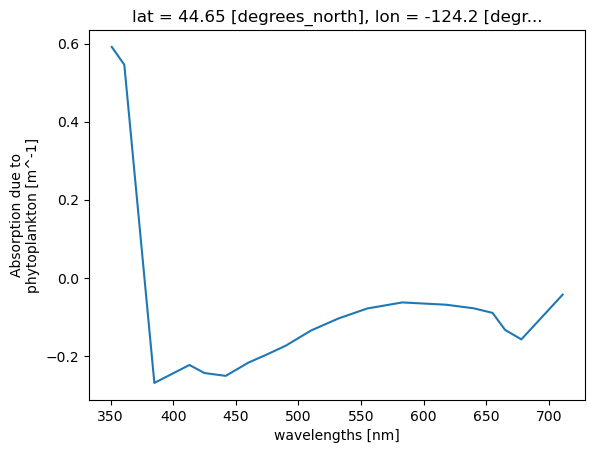

In [21]:
ds_np = ds['aph'].sel(lat=44.6517, lon=-124.1770, method='nearest')
ds_np.plot();

### Multiple months

In [22]:
ds = xr.open_mfdataset(
    fileset,
    combine='nested', concat_dim="time"
)
ds

<xarray.Dataset> Size: 5GB
Dimensions:     (time: 10, lat: 1800, lon: 3600, wavelength: 19, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * wavelength  (wavelength) float64 152B 351.0 361.0 385.0 ... 678.0 711.0
  * lat         (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon         (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: time, rgb, eightbitcolor
Data variables:
    aph         (time, lat, lon, wavelength) float32 5GB dask.array<chunksize=(1, 16, 1024, 8), meta=np.ndarray>
    palette     (time, rgb, eightbitcolor) uint8 8kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/64)
    product_name:                      PACE_OCI.20240301_20240331.L3m.MO.IOP....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/IOP/3.0
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         3016341
    data_minimum:                      -0.7766001
    data_maximum:                      5.0000014

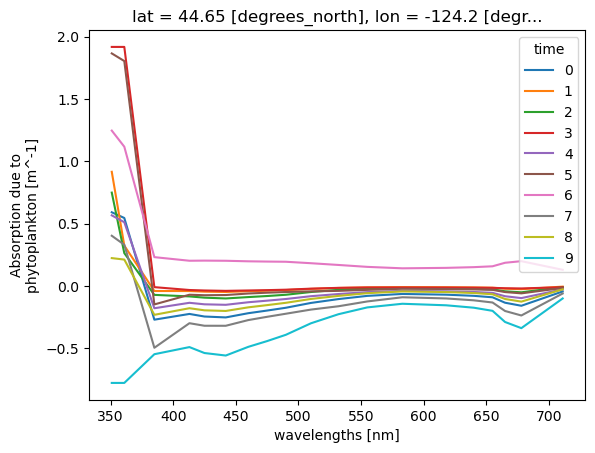

In [23]:
ds_np = ds['aph'].sel(lat=44.6517, lon=-124.1770, method='nearest')
ds_np.plot.line(x="wavelength");

### Raster plots of the APH

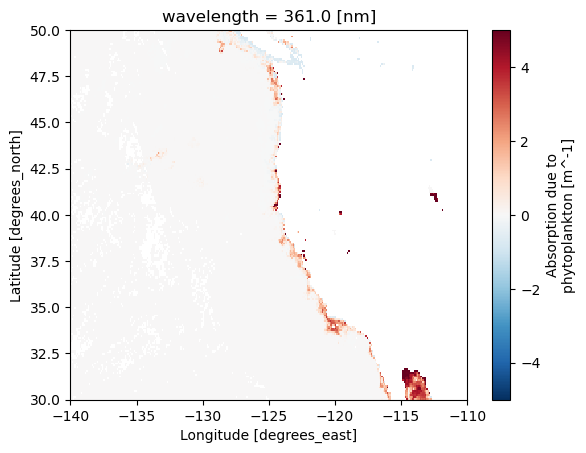

In [24]:
ds["aph"].isel(time=0).sel(wavelength = 361, lat = slice(50, 30), lon=slice(-140, -110)).plot();

In [26]:
ds["wavelength"].values

array([351., 361., 385., 413., 425., 442., 460., 475., 490., 510., 532.,
       555., 583., 618., 640., 655., 665., 678., 711.])

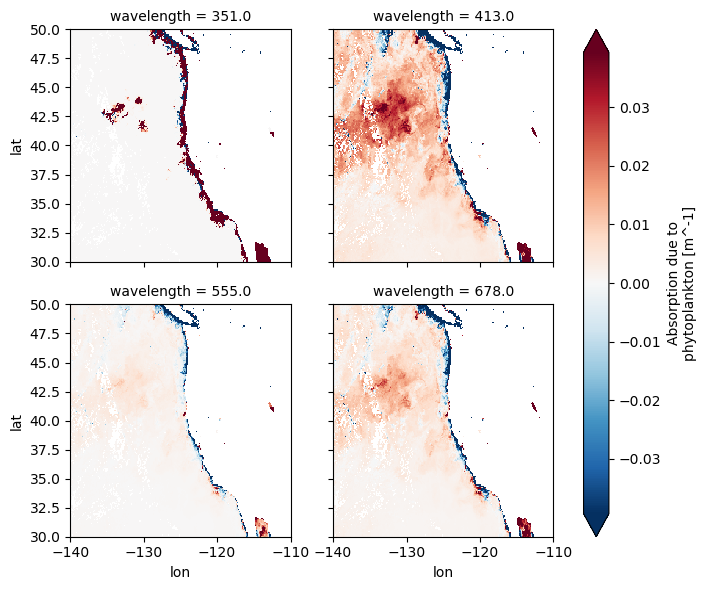

In [37]:
ds["aph"].isel(time=0).sel(
    lat=slice(50, 30), 
    lon=slice(-140, -110), 
    wavelength=[351, 413, 555, 678]  # choose your wavelengths
).plot(x="lon", y="lat", col="wavelength", col_wrap=2, robust=True);

## References

* [An Introduction to Earth and Environmental Data Science](https://earth-env-data-science.github.io)
* [xarray user guide](https://docs.xarray.dev/en/stable/user-guide/index.html)